# Electrical Time Series Data Classification with FCN

## Data Preparation

### Data Loading

In [ ]:
import pandas as pd
import argparse
import numpy as np
import pickle
import os
from google.colab import drive

drive.mount('/content/drive')

save_dir = "/content/drive/My Drive/TimeSeries/Shelly/20022025"
save_path = os.path.join(save_dir, "data_sliding.pkl")

with open(save_path, "rb") as f:
    ed_data, ed_labels = pickle.load(f)

print("\nData loaded successfully from Google Drive.")
print("Data shape:", ed_data.shape)
print("Labels shape:", ed_labels.shape)

Mounted at /content/drive

Data loaded successfully from Google Drive.
Data shape: (42353, 30, 5)
Labels shape: (42353,)


### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

y = ed_labels

try:
    X_train, X_test, y_train, y_test = train_test_split(
        ed_data, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Data split successfully with stratification.")
except ValueError:
    print("Stratified split failed, falling back to random split!")
    X_train, X_test, y_train, y_test = train_test_split(
        ed_data, y, test_size=0.2, random_state=42
    )

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Data split successfully with stratification.
X_train shape: (33882, 30, 5), y_train shape: (33882,)
X_test shape: (8471, 30, 5), y_test shape: (8471,)


### Data Cleaning

In [ ]:
import numpy as np

X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

print("NaN & Inf values cleaned.")


NaN & Inf values cleaned.


### Data Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

num_samples, num_timesteps, num_features = X_train.shape

scalers = [MinMaxScaler() for _ in range(num_features)]

X_train_normalized = np.array([
    scalers[i].fit_transform(X_train[:, :, i]) for i in range(num_features)
]).transpose(1, 2, 0)

X_test_normalized = np.array([
    scalers[i].transform(X_test[:, :, i]) for i in range(num_features)
]).transpose(1, 2, 0)

print("Data normalization complete.")

Data normalization complete.


### Validation Set Splitting

In [ ]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_normalized, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Final dataset split: ")
print(f"X_train_final shape: {X_train_final.shape}, y_train_final shape: {y_train_final.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test_normalized.shape}, y_test shape: {y_test.shape}")

Final dataset split: 
X_train_final shape: (27105, 30, 5), y_train_final shape: (27105,)
X_val shape: (6777, 30, 5), y_val shape: (6777,)
X_test shape: (8471, 30, 5), y_test shape: (8471,)


### One-Hot Encoding

In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train))

y_train_final = to_categorical(y_train_final, num_classes=num_classes)
y_val = to_categorical(y_val, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print(f"One-hot encoding complete. New y_train shape: {y_train_final.shape}")

One-hot encoding complete. New y_train shape: (27105, 9)


### Dataset Size

In [ ]:
import numpy as np

train_size_bytes = X_train_normalized.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 38.77 MB


## FCN Model

### Building

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model

def build_fcn(input_shape=(30, 5), num_classes=9):
    inputs = Input(shape=input_shape)

    x = Conv1D(filters=128, kernel_size=8, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=256, kernel_size=5, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=128, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling1D()(x)  # FCN’in temel özelliği GAP kullanımı

    outputs = Dense(num_classes, activation='softmax')(x)  # Yalnızca çıkış katmanı Dense olur

    model = Model(inputs, outputs)

    return model

fcn_model = build_fcn()

fcn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

fcn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 128)        │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,985 (1.03 MB)

 Trainable params: 269,961 (1.03 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
pip install pydot graphviz

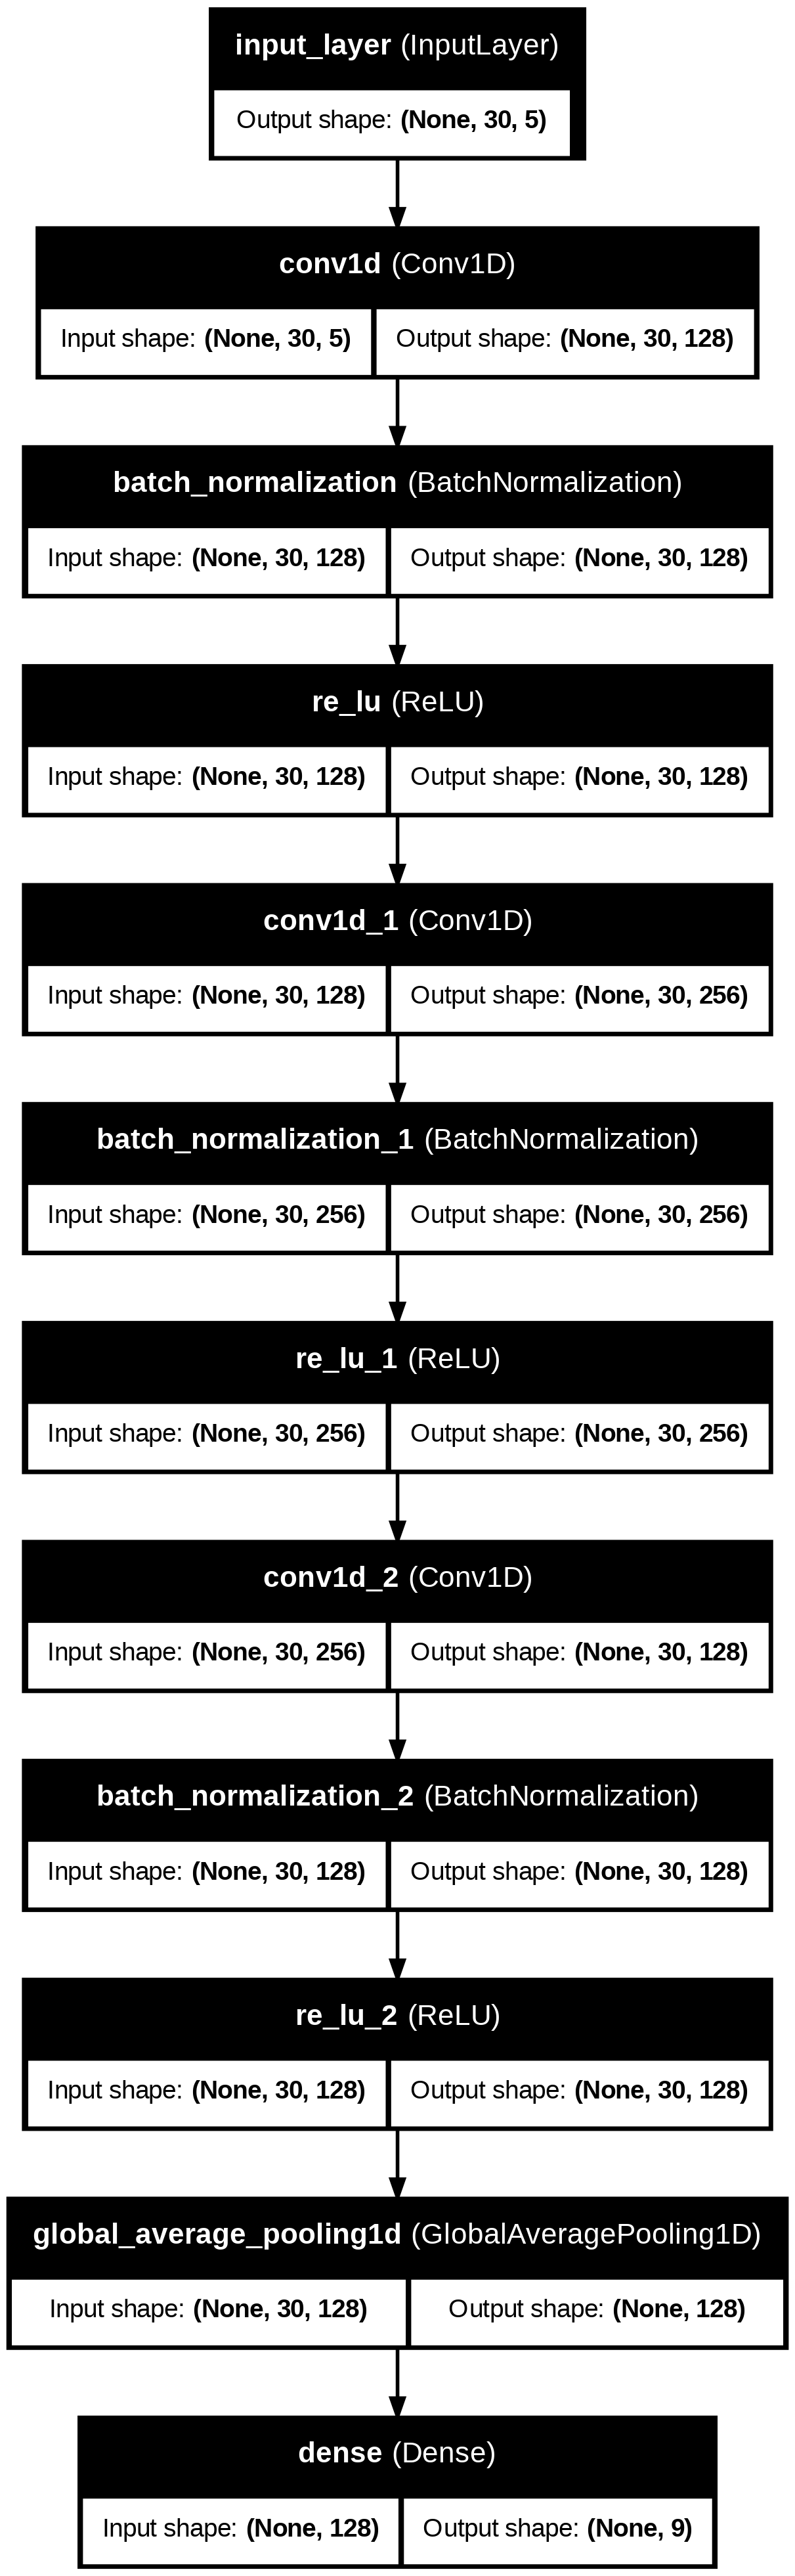

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(fcn_model, to_file="fcn_model.png", show_shapes=True, show_layer_names=True)

### Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def train_fcn(model, X_train, y_train, X_val, y_val,
              epochs=30, batch_size=32, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("best_fcn_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_fcn(fcn_model,
                    X_train_final, y_train_final,
                    X_val, y_val,
                    epochs=50,
                    batch_size=32,
                    save_best_model=True)

Epoch 1/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7982 - loss: 0.5840

848/848 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7982 - loss: 0.5839 - val_accuracy: 0.6763 - val_loss: 0.8242 - learning_rate: 0.0010
Epoch 2/50
834/848 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8726 - loss: 0.3466

848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8727 - loss: 0.3465 - val_accuracy: 0.8597 - val_loss: 0.4373 - learning_rate: 0.0010
Epoch 3/50
838/848 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8849 - loss: 0.3099

848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8850 - loss: 0.3098 - val_accuracy: 0.8523 - val_loss: 0.4234 - learning_rate: 0.0010
Epoch 4/50
833/848 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8987 - loss: 0.2748

848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8988 - loss: 0.2745 - val_accuracy: 0.8660 - val_loss: 0.3094 - learning_rate: 0.0010
Epoch 5/50
839/848 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9145 - loss: 0.2326

...

848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9467 - loss: 0.1334 - val_accuracy: 0.9568 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 16/50
846/848 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9481 - loss: 0.1360

848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9481 - loss: 0.1360 - val_accuracy: 0.9715 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 17/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9536 - loss: 0.1200 - val_accuracy: 0.9304 - val_loss: 0.1736 - learning_rate: 0.0010
Epoch 18/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9530 - loss: 0.1195 - val_accuracy: 0.9548 - val_loss: 0.0996 - learning_rate: 0.0010
Epoch 19/50
839/848 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9524 - loss: 0.1184
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9524 - loss: 0.1183 - val_accuracy: 0.9643 - val_loss: 0.0933 - learning_rate: 0.0010
Epoch 20/50
845/848 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9645 - loss: 0.0920

848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9645 - loss: 0.0920 - val_accuracy: 0.9733 - val_loss: 0.0689 - learning_rate: 5.0000e-04
Epoch 21/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9626 - loss: 0.0921 - val_accuracy: 0.9656 - val_loss: 0.0921 - learning_rate: 5.0000e-04
Epoch 22/50
831/848 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9632 - loss: 0.0930

848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9633 - loss: 0.0929 - val_accuracy: 0.9721 - val_loss: 0.0639 - learning_rate: 5.0000e-04
Epoch 23/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9650 - loss: 0.0891 - val_accuracy: 0.9631 - val_loss: 0.0996 - learning_rate: 5.0000e-04
Epoch 24/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9653 - loss: 0.0858 - val_accuracy: 0.9613 - val_loss: 0.0945 - learning_rate: 5.0000e-04
Epoch 25/50
833/848 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9676 - loss: 0.0833
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9675 - loss: 0.0833 - val_accuracy: 0.9736 - val_loss: 0.0651 - learning_rate: 5.0000e-04
Epoch 26/50
844/848 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9719 - loss: 0.0715

848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9719 - loss: 0.0715 - val_accuracy: 0.9816 - val_loss: 0.0563 - learning_rate: 2.5000e-04
Epoch 27/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9707 - loss: 0.0730 - val_accuracy: 0.9684 - val_loss: 0.0879 - learning_rate: 2.5000e-04
Epoch 28/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9721 - loss: 0.0698 - val_accuracy: 0.9712 - val_loss: 0.0741 - learning_rate: 2.5000e-04
Epoch 29/50
832/848 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9726 - loss: 0.0681
Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9726 - loss: 0.0681 - val_accuracy: 0.9556 - val_loss: 0.1196 - learning_rate: 2.5000e-04
Epoch 30/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9734 - loss: 0.0669 - val_accuracy: 0.9684 - val_loss: 0.0834 - learning_rate: 1.2500e-04
Epoch 31/50
848/848 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9749 - l

## Evaluation

### Training Performance

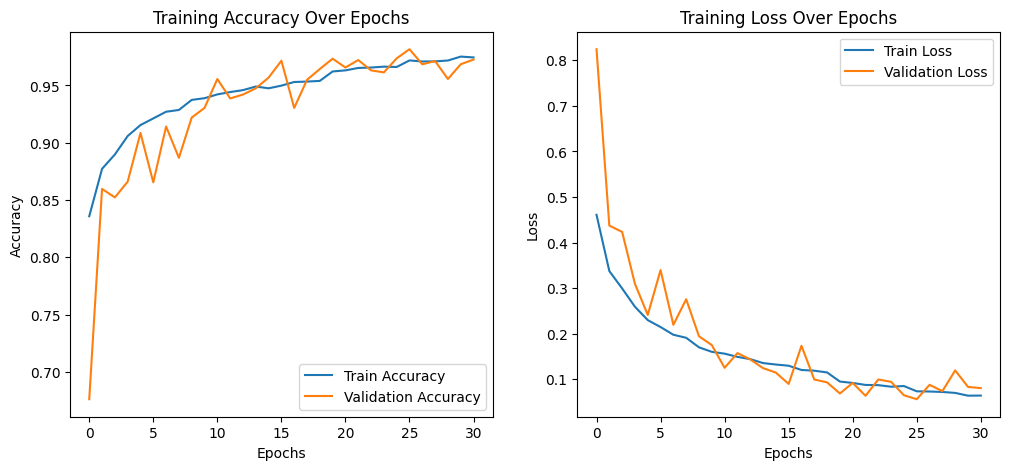

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title("Training Accuracy Over Epochs")

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title("Training Loss Over Epochs")

    plt.show()

plot_training_history(history)

### Classification Metrics

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = fcn_model.predict(X_test_normalized)
y_pred_classes = y_pred.argmax(axis=1)
y_true_classes = y_test.argmax(axis=1)

accuracy = accuracy_score(y_true_classes, y_pred_classes)
class_report = classification_report(y_true_classes, y_pred_classes, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(class_report)

265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test Accuracy: 0.9855

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    0.9894    0.9947       188
           2     0.9878    0.9528    0.9699       508
           3     0.9686    0.9088    0.9378       373
           4     0.9874    0.9919    0.9897      2603
           5     0.9792    0.9974    0.9882      1938
           6     0.9605    1.0000    0.9799       511
           7     0.9773    0.8776    0.9247        98
           8     0.9799    0.9460    0.9626       463

    accuracy                         0.9855      8471
   macro avg     0.9823    0.9627    0.9719      8471
weighted avg     0.9855    0.9855    0.9853      8471



### Confusion Matrix

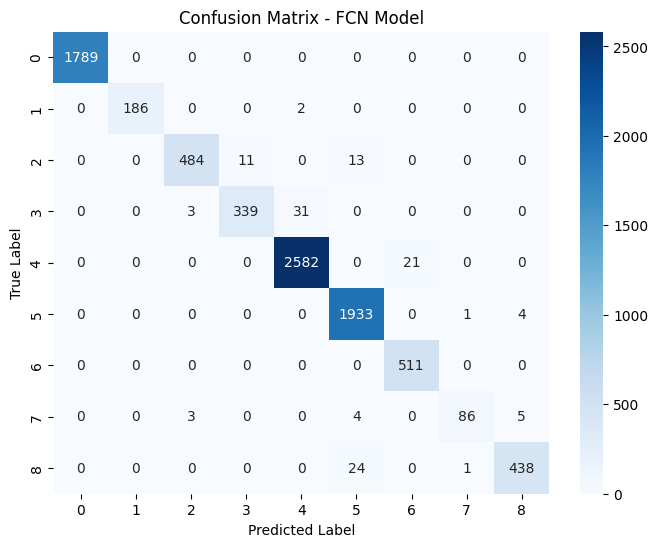

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - FCN Model")
plt.show()

### Model Saving and Size Check

In [ ]:
import os

fcn_model.save("fcn_model.h5")

model_size = os.path.getsize("fcn_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 3.16 MB


## TinyML Performance

### TF Lite Conversion

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(fcn_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

def representative_dataset():
    for sample in X_test_normalized.astype(np.float32):
        yield [np.expand_dims(sample, axis=0)]

converter.representative_dataset = representative_dataset

tflite_quantized_model = converter.convert()

with open("fcn_model_quantized.tflite", "wb") as f:
    f.write(tflite_quantized_model)

print("Quantized model saved: fcn_model_quantized.tflite")


Saved artifact at '/tmp/tmpsi816ty_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  132572138749200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132574032543824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132572132902096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132572138749776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132572138749008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132572132901520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132573912850384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132572132903056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132572132902672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132572132900944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132572132903248: Ten

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized model saved: fcn_model_quantized.tflite


### Evaluation

In [ ]:
interpreter = tf.lite.Interpreter(model_path="fcn_model_quantized.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']

y_pred = []
y_true = np.argmax(y_test, axis=1)

for i in range(len(X_test_normalized)):
    test_sample = X_test_normalized[i:i+1] / input_scale + input_zero_point
    test_sample = np.round(test_sample).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], test_sample)
    interpreter.invoke()

    output_data = interpreter.get_tensor(output_details[0]['index'])
    output_data = (output_data.astype(np.float32) - output_zero_point) * output_scale
    predicted_class = np.argmax(output_data)

    y_pred.append(predicted_class)

y_pred = np.array(y_pred)

print("TFLite model prediction completed on test set.")

TFLite model prediction completed on test set.


### Test Classification Report

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.9839
Precision: 0.9841
Recall: 0.9839
F1-score: 0.9838

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    0.9947    0.9973       188
           2     0.9837    0.9508    0.9670       508
           3     0.9602    0.9062    0.9324       373
           4     0.9881    0.9912    0.9896      2603
           5     0.9773    0.9995    0.9883      1938
           6     0.9623    1.0000    0.9808       511
           7     0.8350    0.8776    0.8557        98
           8     0.9976    0.9158    0.9550       463

    accuracy                         0.9839      8471
   macro avg     0.9671    0.9595    0.9629      8471
weighted avg     0.9841    0.9839    0.9838      8471



### Confusion Matrix

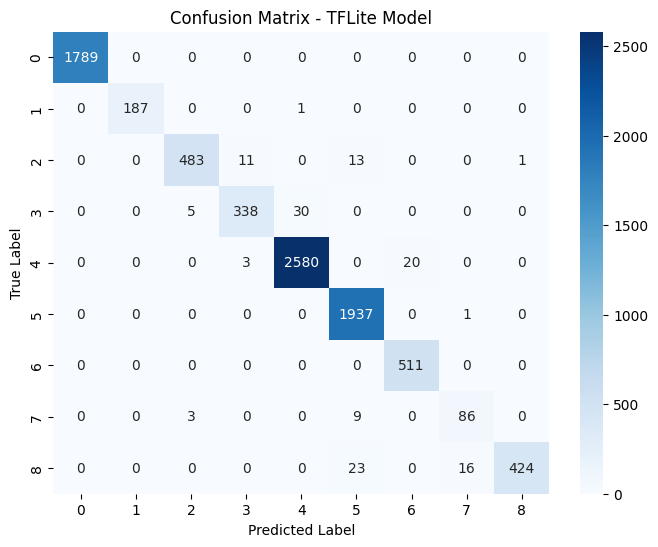

In [ ]:
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - TFLite Model")
plt.show()

### Model Size

In [ ]:
import os

tflite_model_path = "fcn_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 282.84 KB


### ESP32 Compatible Header File Creation

In [ ]:
import numpy as np

tflite_model_path = "fcn_model_quantized.tflite"
with open(tflite_model_path, "rb") as f:
    tflite_model = f.read()

c_array = ', '.join(str(b) for b in tflite_model)

header_text = f"""#ifndef FCN_MODEL_H
#define FCN_MODEL_H

alignas(8) const unsigned char fcn_model[] = {{
    {c_array}
}};

const unsigned int fcn_model_len = {len(tflite_model)};

#endif  // FCN_MODEL_H
"""

header_file_path = "fcn_model.h"
with open(header_file_path, "w") as f:
    f.write(header_text)

print(f"C++ header file created for ESP32: {header_file_path}")

C++ header file created for ESP32: fcn_model.h


### ESP32 Memory Results

In [ ]:
import pandas as pd

esp32_info = {
    "Parameter": [
        "CPU Cores",
        "CPU Frequency (MHz)",
        "Total Heap Memory (KB)",
        "Flash Memory Size (MB)"
    ],
    "Value": [
        2,
        240,
        355,
        4
    ]
}

df_esp32_info = pd.DataFrame(esp32_info)

df_esp32_info

### ESP32 Inference Results

In [ ]:
inference_results = {
    "Parameter": [
        "Model Input Scale",
        "Model Input Zero Point",
        "Model Output Scale",
        "Model Output Zero Point",
        "Prediction Result",
        "Model Prediction Class",
        "Inference Time (s)",
        "Model Memory Usage (KB)"
    ],
    "Value": [
        0.003955,
        -126,
        0.003906,
        -128,
        "0.000000, 0.000000, 0.187500, 0.789062, 0.000000, 0.000000, 0.023437, 0.000000, 0.000000, 0.000000",
        3,
        0.53,
        20.65
    ]
}

df_inference_results = pd.DataFrame(inference_results)

df_inference_results

,Parameter,Value
0,Model Input Scale,0.003955
1,Model Input Zero Point,-126
2,Model Output Scale,0.003906
3,Model Output Zero Point,-128
4,Prediction Result,"0.000000, 0.000000, 0.187500, 0.789062, 0.0000..."
5,Model Prediction Class,3
6,Inference Time (s),0.53
7,Model Memory Usage (KB),20.65
